# Ciencia de Datos
## Aprendizaje No Supervizado: Reducción de Dimensionalidad
### Análisis de Componentes Principales (PCA)

Autor: Mariano Martín Gualpa (mgualpa@frc.utn.edu.ar)

Cargamos Librerías

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Cargamos el conjunto de datos Iris.

In [25]:
# Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data  # Características
y = iris.target  # Etiquetas de clase

In [26]:
df = pd.DataFrame(X, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Definimos colores que utlizaremos para identificar las clases 1, 2 y 3.

In [27]:
colors = ['navy', 'turquoise', 'darkorange']

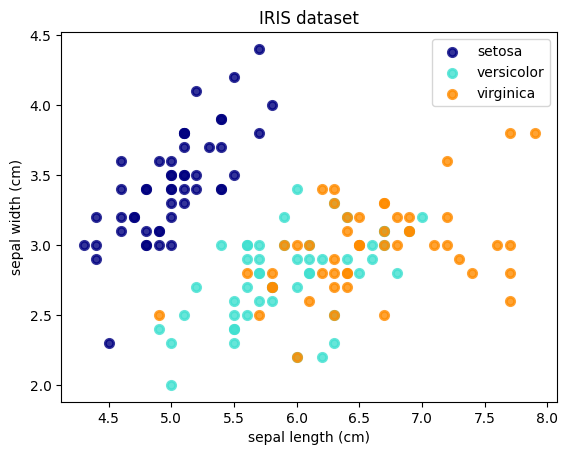

In [28]:
f1 = 0
f2 = 1
plt.figure()
lw = 2  # Ancho de línea

for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X[y == i, f1], X[y == i, f2], color=color, alpha=.8, lw=lw,
                label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('IRIS dataset')
plt.xlabel(iris.feature_names[f1])
plt.ylabel(iris.feature_names[f2])

plt.show()

Generamos un gráfico 3D para ver los datos en tres de las cuatro dimensiones.

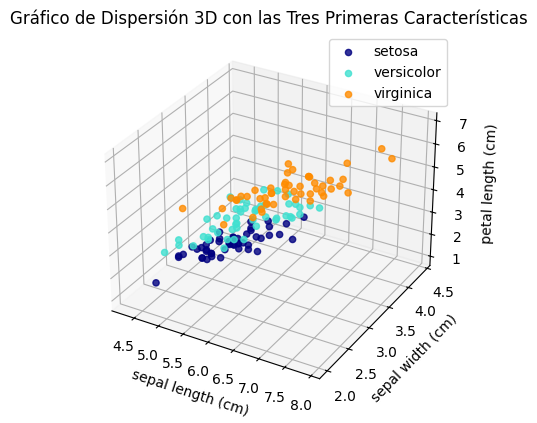

In [29]:
# Crear una figura 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Crear un gráfico de dispersión 3D
for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    ax.scatter(X[y == i, 0], X[y == i, 1], X[y == i, 2], color=color, alpha=0.8, label=target_name)

# Etiquetas y título
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.set_title('Gráfico de Dispersión 3D con las Tres Primeras Características')

# Leyenda
ax.legend(loc='best')

plt.show()

### Reducción de Dimensionalidad
Ahora aplicaremos PCA para reducir la dimensionalidad.

In [30]:
scaler = StandardScaler()
X_std = scaler.fit_transform(df)

Reducción de dimensionalidad con PCA a 2 componentes


In [31]:
pca = PCA(n_components=2)
X_r = pca.fit_transform(X_std)

In [32]:
X_r[:5,:]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538]])

Generar un gráfico posicionando cada tupla en el gráfico pero usando unicamente las dos componentes principales.

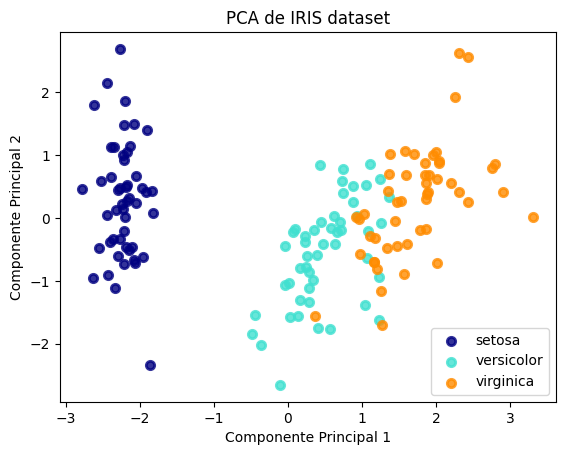

In [33]:
plt.figure()
lw = 2  # Ancho de línea

for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_r[y == i, 0], X_r[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA de IRIS dataset')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

### Proporción de la Varianza Explicada

In [34]:
pve = pca.explained_variance_ratio_

In [35]:
print("Proporción de Varianza Explicada (PVE):")
for i, var_ratio in enumerate(pve):
    print(f"Componente Principal {i + 1}: {var_ratio:.2f}")


Proporción de Varianza Explicada (PVE):
Componente Principal 1: 0.73
Componente Principal 2: 0.23


## Ejemplo de Aplicación

In [36]:
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
#from sklearn.preprocessing import StandardScaler
#from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from matplotlib.lines import Line2D


Volvemos a cargar el dataset

In [37]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

Partimos el dataset en entreamiento y test (train/test)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


Definimos el pipeline con estandarización, PCA opcional y Regresión Logística (tener en cuenta que como el dataset tiene una variable objetivo con más de dos categorías, automáticamente aplica el modelo de regresión multinomial).

In [39]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),  # n_components será definido en GridSearch
    ('clf', LogisticRegression(max_iter=1000, solver='lbfgs'))
])


Definición de parámetros de búsqueda.

In [40]:
param_grid = {
    'pca__n_components': [None, 1, 2, 3, 4],  # None = no PCA
    'clf__C': [0.01, 0.1, 1, 10, 100]
}


Declaración de KFold y la búsqueda en grilla.

In [41]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=kf, scoring='accuracy', return_train_score=True)
grid.fit(X_train, y_train)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'clf__C': [0.01, 0.1, 1, 10, 100],
                         'pca__n_components': [None, 1, 2, 3, 4]},
             return_train_score=True, scoring='accuracy')

Mostrar resultados de GridSearch.

In [42]:
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[['param_pca__n_components', 'param_clf__C', 'mean_test_score']]
print("Tabla de Accuracy promedio por combinación de hiperparámetros:\n")
print(results_table)

Tabla de Accuracy promedio por combinación de hiperparámetros:

   param_pca__n_components  param_clf__C  mean_test_score
0                     None          0.01         0.761905
1                        1          0.01         0.714286
2                        2          0.01         0.761905
3                        3          0.01         0.761905
4                        4          0.01         0.761905
5                     None          0.10         0.885714
6                        1          0.10         0.866667
7                        2          0.10         0.857143
8                        3          0.10         0.885714
9                        4          0.10         0.885714
10                    None          1.00         0.971429
11                       1          1.00         0.885714
12                       2          1.00         0.876190
13                       3          1.00         0.971429
14                       4          1.00         0.971429
15      

Identificamos el mejor modelo.

In [43]:
best_model = grid.best_estimator_
print("\nMejor modelo encontrado:\n")
print("PCA n_components:", best_model.named_steps['pca'].n_components)
print("LogisticRegression parameters:", best_model.named_steps['clf'])



Mejor modelo encontrado:

PCA n_components: 3
LogisticRegression parameters: LogisticRegression(C=100, max_iter=1000)


Realizar predicciones.

In [44]:
y_pred = best_model.predict(X_test)


Para graficar generaremos dos ejes con PCA

In [45]:
# 1. Estandarizar los datos de test para visualización
scaler_vis = StandardScaler()
X_test_scaled = scaler_vis.fit_transform(X_test)  # solo para visualizar

# 2. Aplicar un PCA de 2 componentes solo para visualización
pca_vis = PCA(n_components=2)
X_test_transformed = pca_vis.fit_transform(X_test_scaled)

Graficamos.

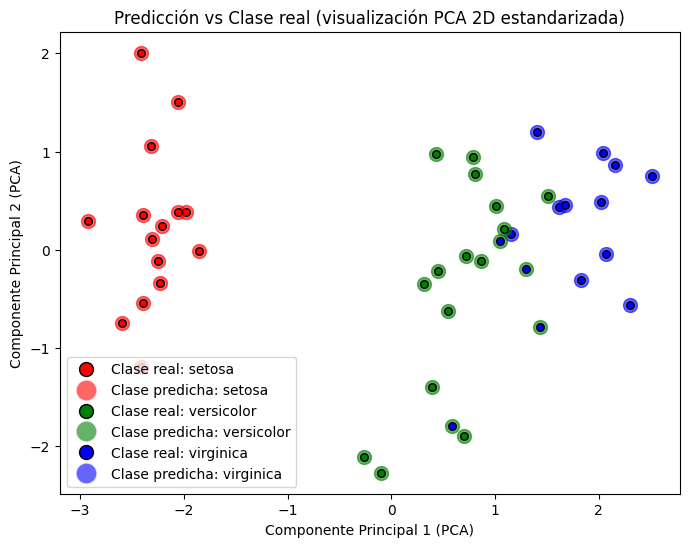

In [46]:
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']
class_labels = target_names

# Graficar puntos
for i in range(len(y_test)):
    # Punto grande: predicción
    plt.scatter(X_test_transformed[i, 0], X_test_transformed[i, 1],
                color=colors[y_pred[i]], s=100, alpha=0.6)
    # Punto pequeño: clase real
    plt.scatter(X_test_transformed[i, 0], X_test_transformed[i, 1],
                color=colors[y_test[i]], s=30, alpha=1, edgecolor='k')

legend_elements = []
for idx, name in enumerate(class_labels):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'Clase real: {name}',
                                  markerfacecolor=colors[idx], markersize=10, markeredgecolor='k'))
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=f'Clase predicha: {name}',
                                  markerfacecolor=colors[idx], markersize=15, alpha=0.6))
plt.legend(handles=legend_elements, loc='best')
plt.xlabel("Componente Principal 1 (PCA)")
plt.ylabel("Componente Principal 2 (PCA)")
plt.title("Predicción vs Clase real (visualización PCA 2D estandarizada)")
plt.show()
